In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss

from debugger import bug_check


In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=16,
    in_chans=3,
    embed_dim=256,
    depth=4,
    num_heads=4,
    num_bins=32,
    dropout=0.1,
).to(device)

In [5]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debugg=False,
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)


In [6]:
# bug_check(0)

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

model.train()
for epoch in range(10):
    total = 0.0

    for batch in loader:
        img_a, vision_a, img_b, vision_b, pose_ab = batch

        img_a = img_a.to(device, non_blocking=True)
        img_b = img_b.to(device, non_blocking=True)
        vision_a = vision_a.to(device, non_blocking=True)
        vision_b = vision_b.to(device, non_blocking=True)
        pose_ab = pose_ab.to(device, non_blocking=True)

        pred_vision, pred_pose = model(img_a, img_b)

        losses = supervised_loss(pred_vision, vision_a, vision_b,
            pred_pose,pose_ab, lambda_pose=1.0,
        )

        loss = losses["total"]

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()

    print(f"Epoch {epoch+1}: loss={total / len(loader):.4f}")

No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
Epoch 1: loss=13.6626
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
Epoch 2: loss=13.8150
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
No, this is not correct!
Epoch 3: loss=12.5351
No, this is not correct!
No, this 

In [8]:
# Inference + utskrift + plottar på samma dataset som träningen
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Samma dataset som i träningen, men utan shuffle för stabil visualisering
infer_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

def pose_to_text(pose_4):
    """
    pose_4: tensor [tx, ty, sin(yaw), cos(yaw)]
    """
    tx, ty, s, c = pose_4.tolist()
    yaw_deg = np.degrees(np.arctan2(s, c))
    return f"tx={tx:.3f}, ty={ty:.3f}, yaw={yaw_deg:.1f}°"

def show_image_pair(img_a, img_b, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_a.permute(1, 2, 0).cpu().clamp(0, 1))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b.permute(1, 2, 0).cpu().clamp(0, 1))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
vision_b = vision_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, pred_pose = model(img_a, img_b)

# Skriv ut resultat för några samples
n_show = min(4, img_a.shape[0])
for i in range(n_show):
    print(f"Sample {i}")
    print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
    print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

    pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
    print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
    print()

Sample 0
  GT   pose: tx=-0.151, ty=-0.989, yaw=-6.8°
  Pred pose: tx=-0.045, ty=0.085, yaw=1.8°
  |err|     : tx=0.106, ty=1.074, sin=0.149, cos=0.006

Sample 1
  GT   pose: tx=-0.910, ty=-0.415, yaw=-7.9°
  Pred pose: tx=-0.047, ty=0.077, yaw=1.4°
  |err|     : tx=0.863, ty=0.492, sin=0.162, cos=0.009

Sample 2
  GT   pose: tx=0.416, ty=0.909, yaw=-12.7°
  Pred pose: tx=-0.046, ty=0.084, yaw=1.4°
  |err|     : tx=0.462, ty=0.825, sin=0.245, cos=0.024

Sample 3
  GT   pose: tx=-0.520, ty=0.854, yaw=4.8°
  Pred pose: tx=-0.046, ty=0.085, yaw=1.5°
  |err|     : tx=0.474, ty=0.770, sin=0.057, cos=0.003



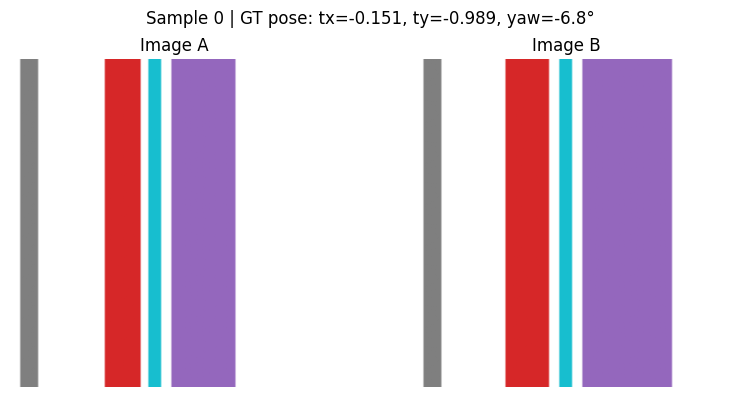

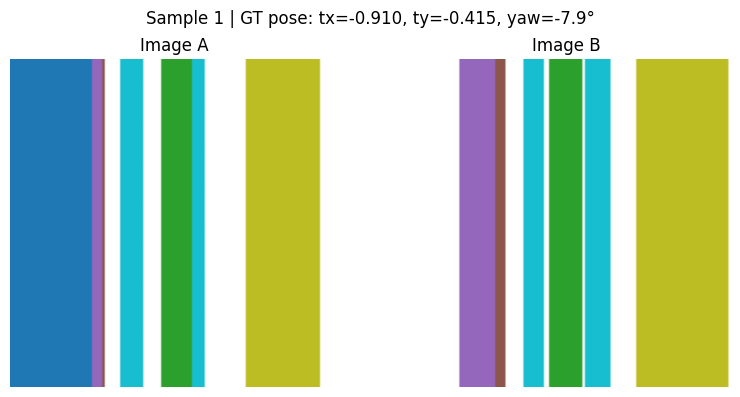

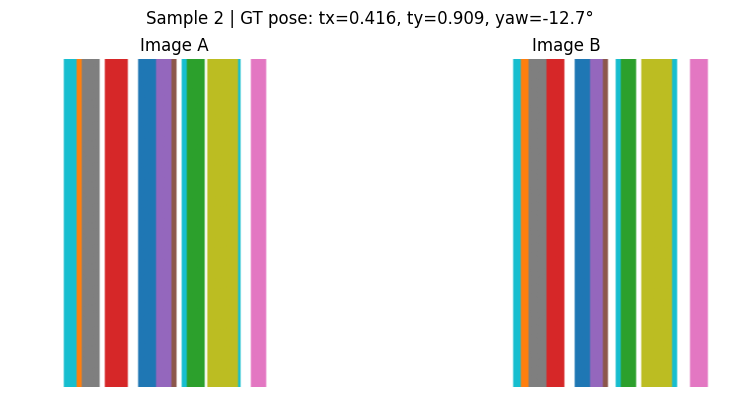

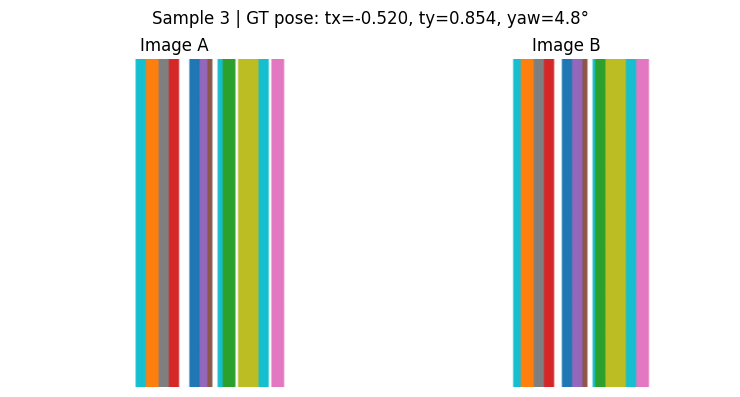

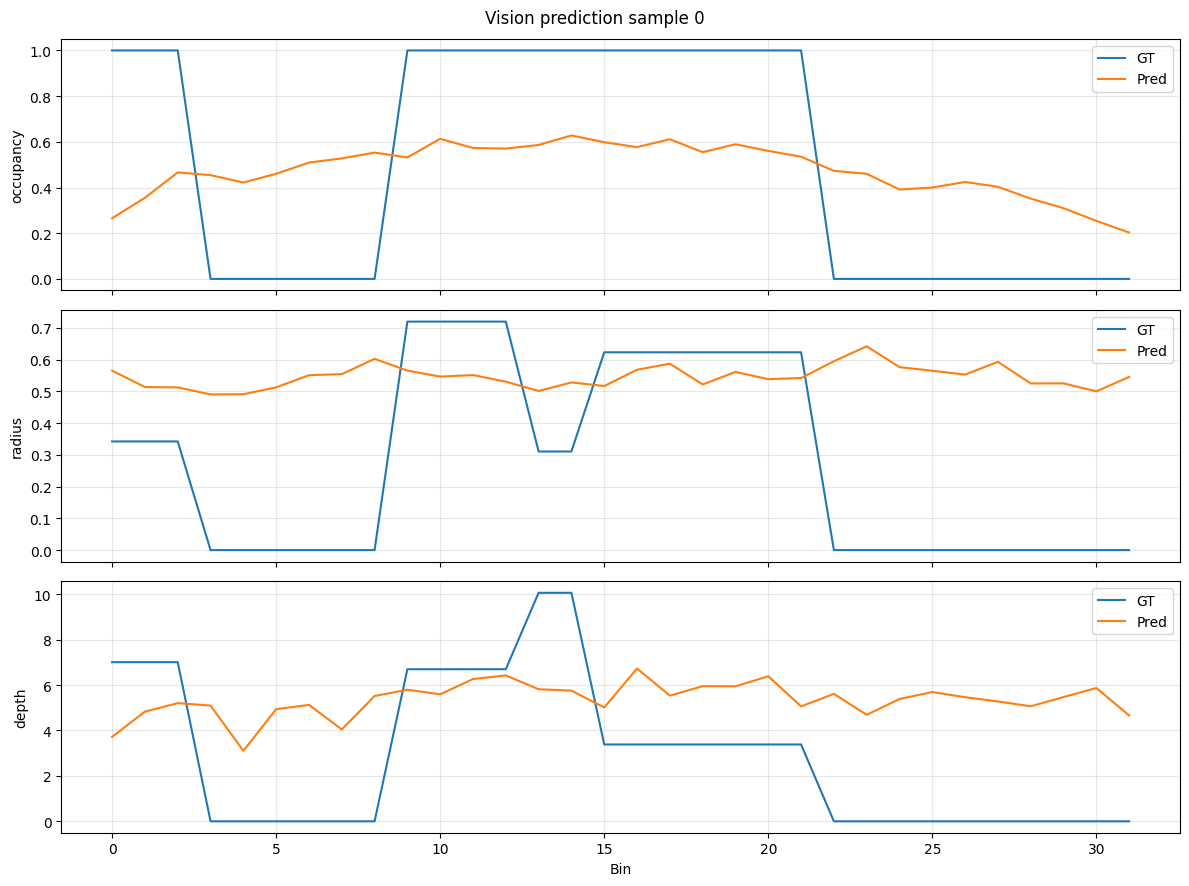

In [9]:
# Plotta bildpar
for i in range(n_show):
    show_image_pair(
        img_a[i].detach().cpu(),
        img_b[i].detach().cpu(),
        title=f"Sample {i} | GT pose: {pose_to_text(pose_ab[i].detach().cpu())}"
    )

# Plotta vision-output för första samplet
sample_idx = 0
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    ax.plot(bins, gt, label="GT")
    ax.plot(bins, pr, label="Pred")
    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()